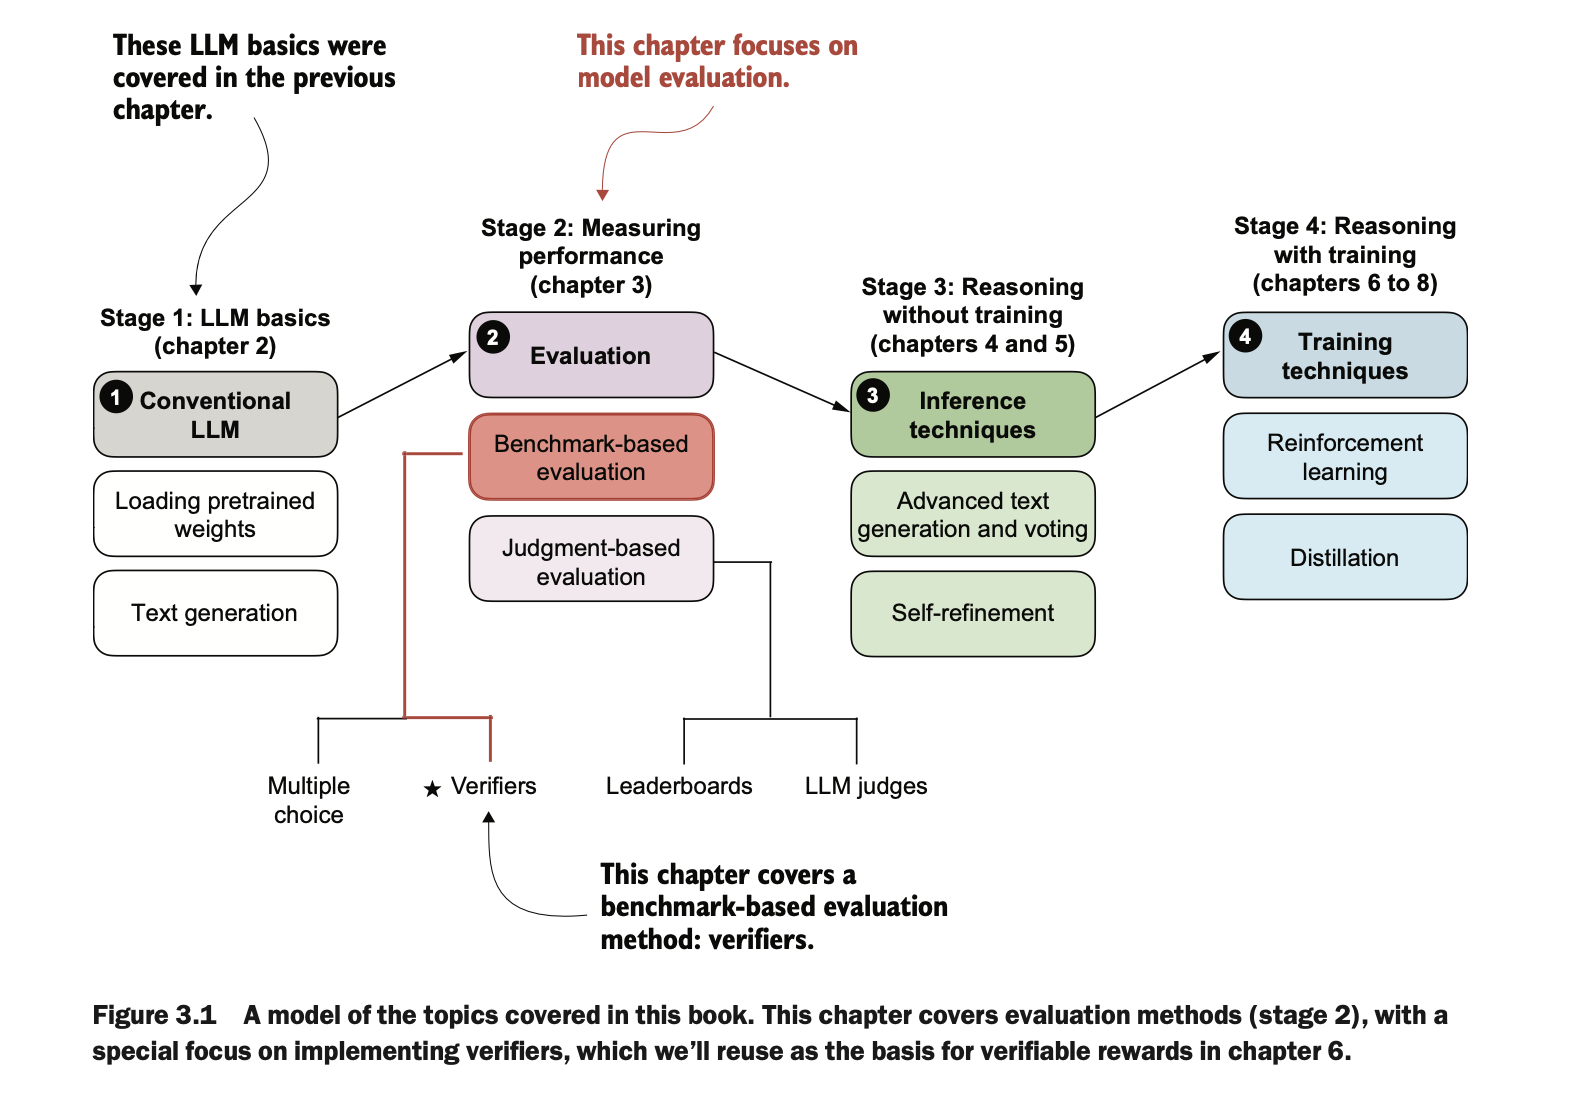


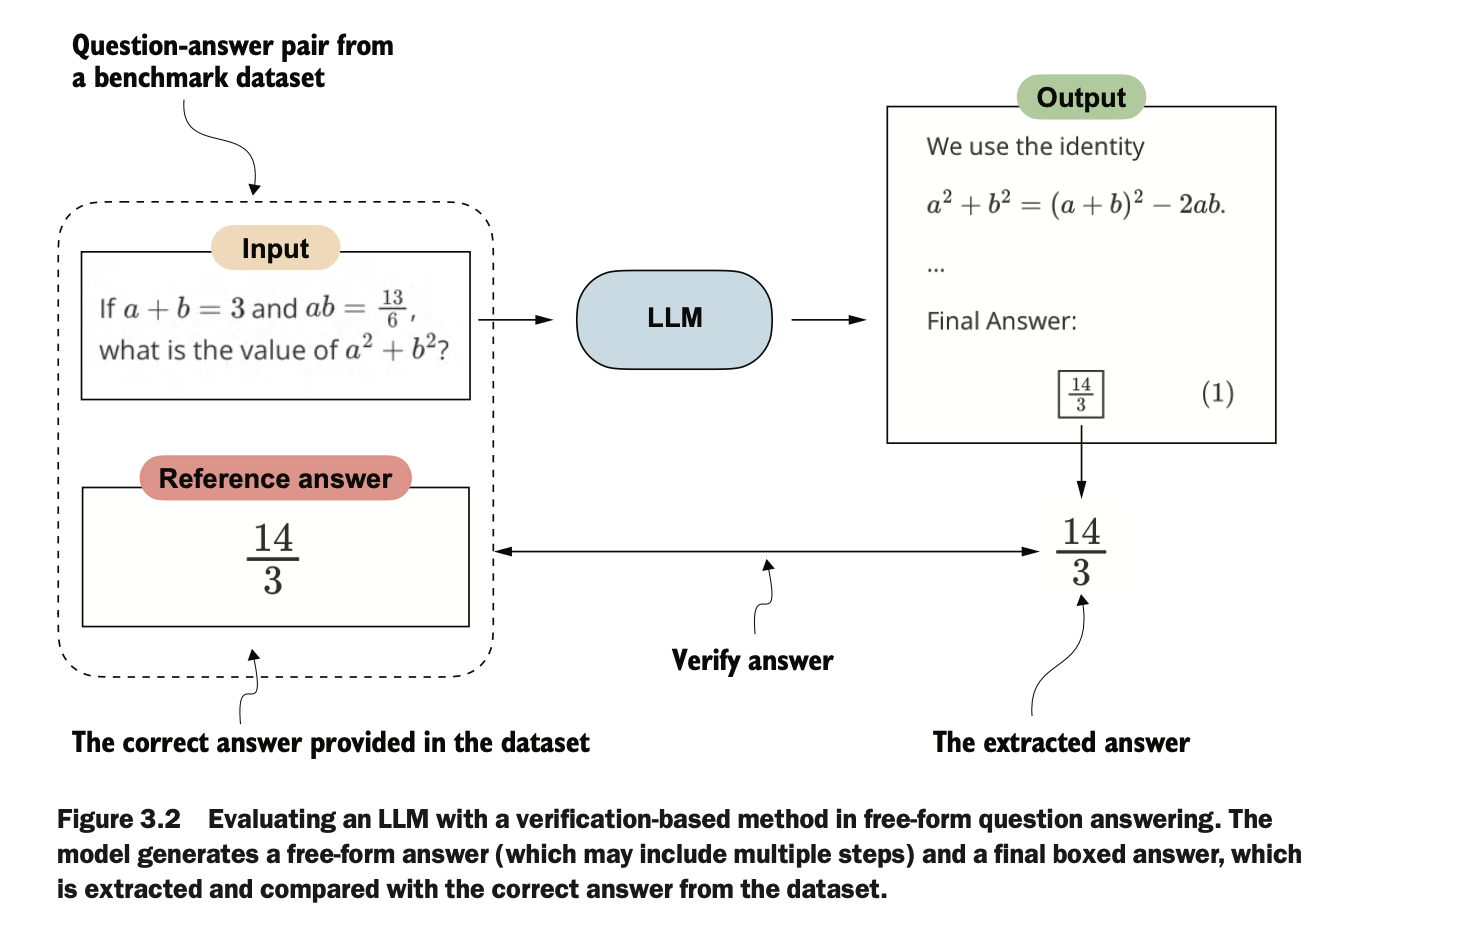


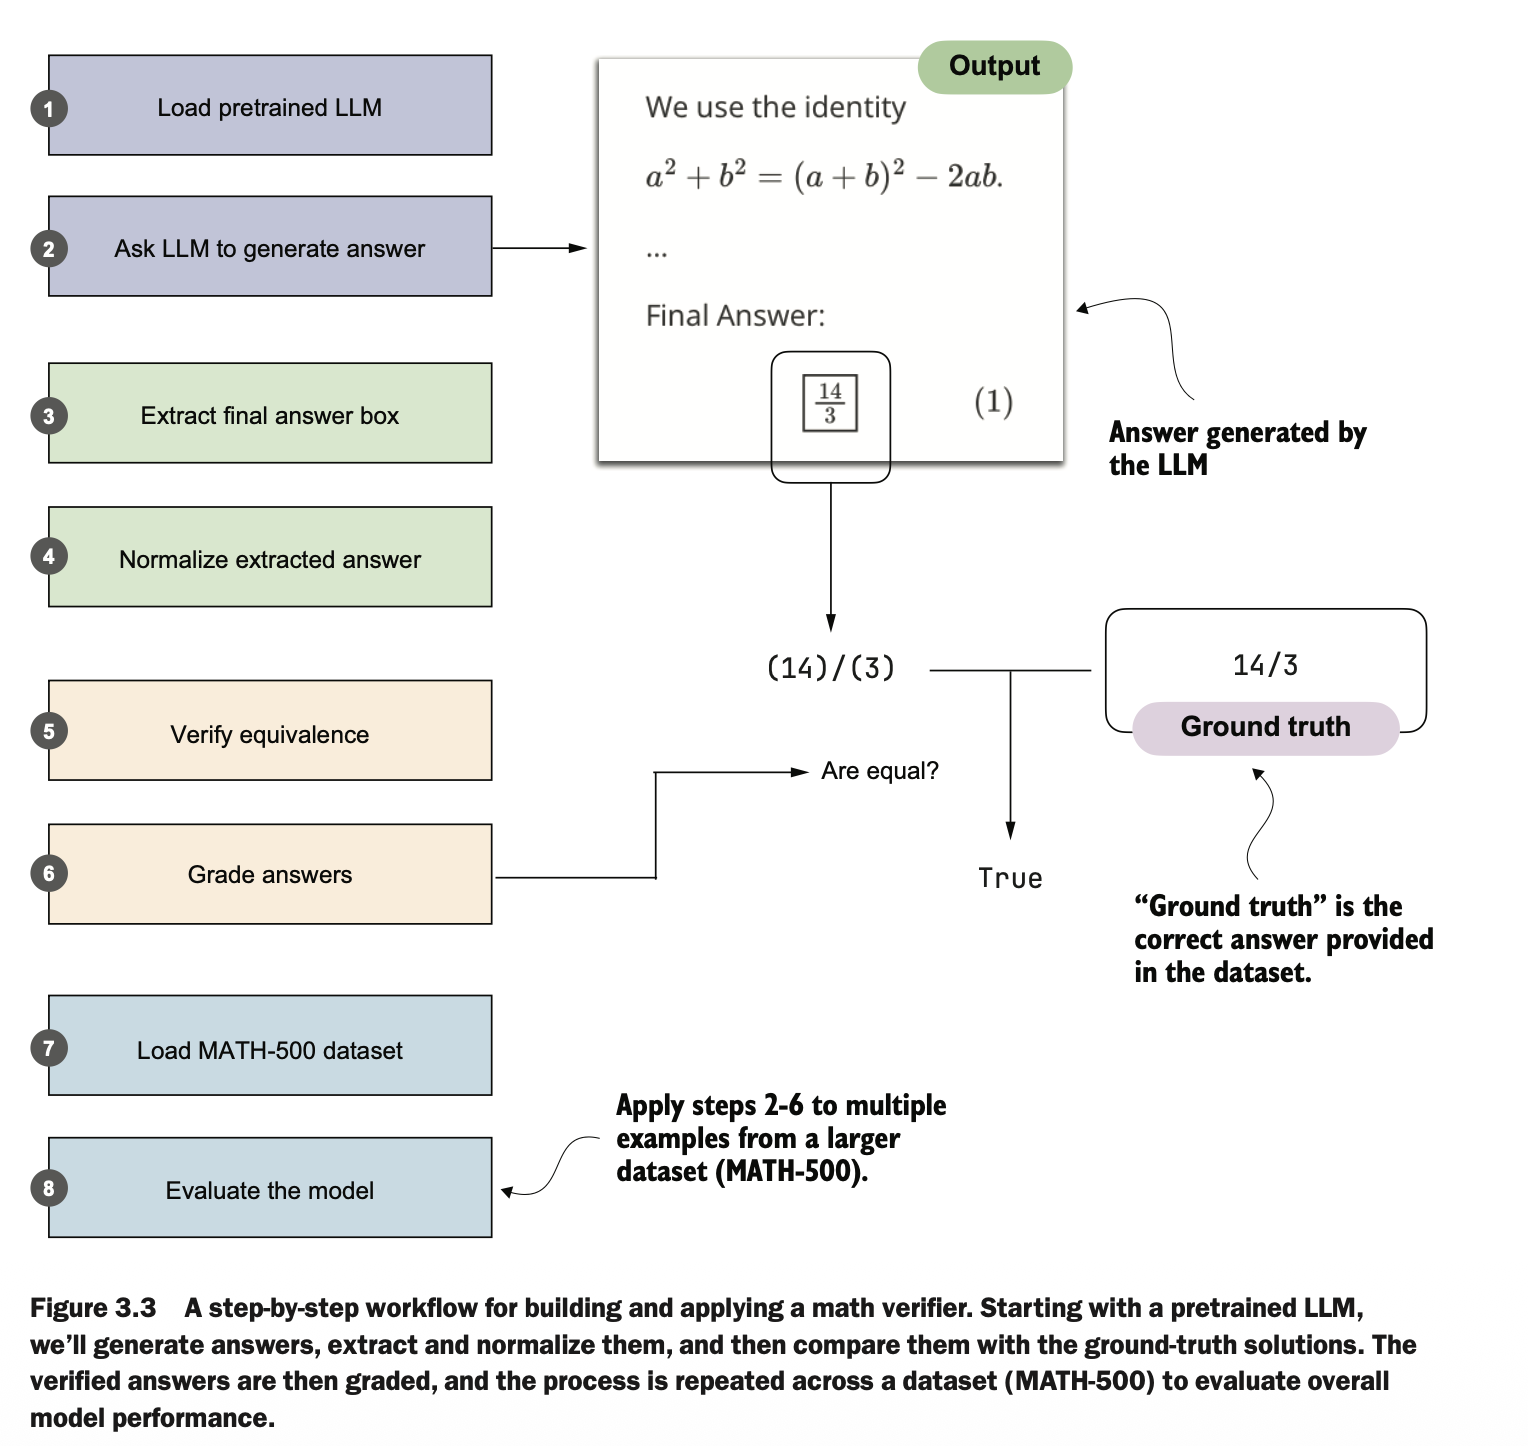


In [ ]:
from pathlib import Path
import torch


from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer,
    Qwen3Model,
    QWEN_CONFIG_06_B,
)


def load_model_and_tokenizer(which_model, device, use_compile, local_dir="qwen3"):
    if which_model == "base":

        download_qwen3_small(kind="base", tokenizer_only=False, out_dir=local_dir)

        tokenizer_path = Path(local_dir) / "tokenizer-base.json"
        model_path = Path(local_dir) / "qwen3-0.6B-base.pth"
        tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path) # type: ignore

    elif which_model == "reasoning":

        download_qwen3_small(kind="reasoning", tokenizer_only=False, out_dir=local_dir)

        tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
        model_path = Path(local_dir) / "qwen3-0.6B-reasoning.pth"
        tokenizer = Qwen3Tokenizer(
            tokenizer_file_path=tokenizer_path, # type: ignore
            apply_chat_template=True,
            add_generation_prompt=True,
            add_thinking=True,
        )

    else:
        raise ValueError(f"Invalid choice: which_model={which_model}")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(torch.load(model_path))

    model.to(device)

    if use_compile:
        torch._dynamo.config.allow_unspec_int_on_nn_module = True
        model = torch.compile(model)

    return model, tokenizer

In [5]:
from reasoning_from_scratch.ch02 import get_device

WHICH_MODEL = "base"
device = get_device()

# If you have compatibility issues, try to
# uncomment the line below and rerun the notebook
# device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model=WHICH_MODEL, device=device, use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [6]:
from reasoning_from_scratch.ch02 import generate_text_basic_stream_cache

prompt = r"If $a+b=3$ and $ab=\tfrac{13}{6}$, " r"what is the value of $a^2+b^2$?"

# Similar to chapter 2 exercise solution:
input_token_ids_tensor = torch.tensor(
    tokenizer.encode(prompt), device=device
).unsqueeze(0)

all_token_ids = []
for token in generate_text_basic_stream_cache(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=2048,
    eos_token_id=tokenizer.eos_token_id,
):
    token_id = token.squeeze(0)
    decoded_id = tokenizer.decode(token_id.tolist())
    print(decoded_id, end="", flush=True)
    all_token_ids.append(token_id)

all_tokens = tokenizer.decode(all_token_ids)

 To find the value of \( a^2 + b^2 \) given that \( a + b = 3 \) and \( ab = \frac{13}{6} \), we can use the following algebraic identity:

\[
a^2 + b^2 = (a + b)^2 - 2ab
\]

**Step 1:** Substitute the given values into the equation.

\[
a^2 + b^2 = (3)^2 - 2 \left( \frac{13}{6} \right)
\]

**Step 2:** Calculate \( (3)^2 \).

\[
(3)^2 = 9
\]

**Step 3:** Calculate \( 2 \times \frac{13}{6} \).

\[
2 \times \frac{13}{6} = \frac{26}{6} = \frac{13}{3}
\]

**Step 4:** Subtract the second result from the first.

\[
a^2 + b^2 = 9 - \frac{13}{3}
\]

**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.

\[
9 = \frac{27}{3}
\]

\[
a^2 + b^2 = \frac{27}{3} - \frac{13}{3} = \frac{14}{3}
\]

**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]

In [7]:
# render the latex text in a more readable format
from IPython.display import Latex, display

display(Latex(all_tokens))

<IPython.core.display.Latex object>

# 3.3 Implementing a wrapper for easier text generation

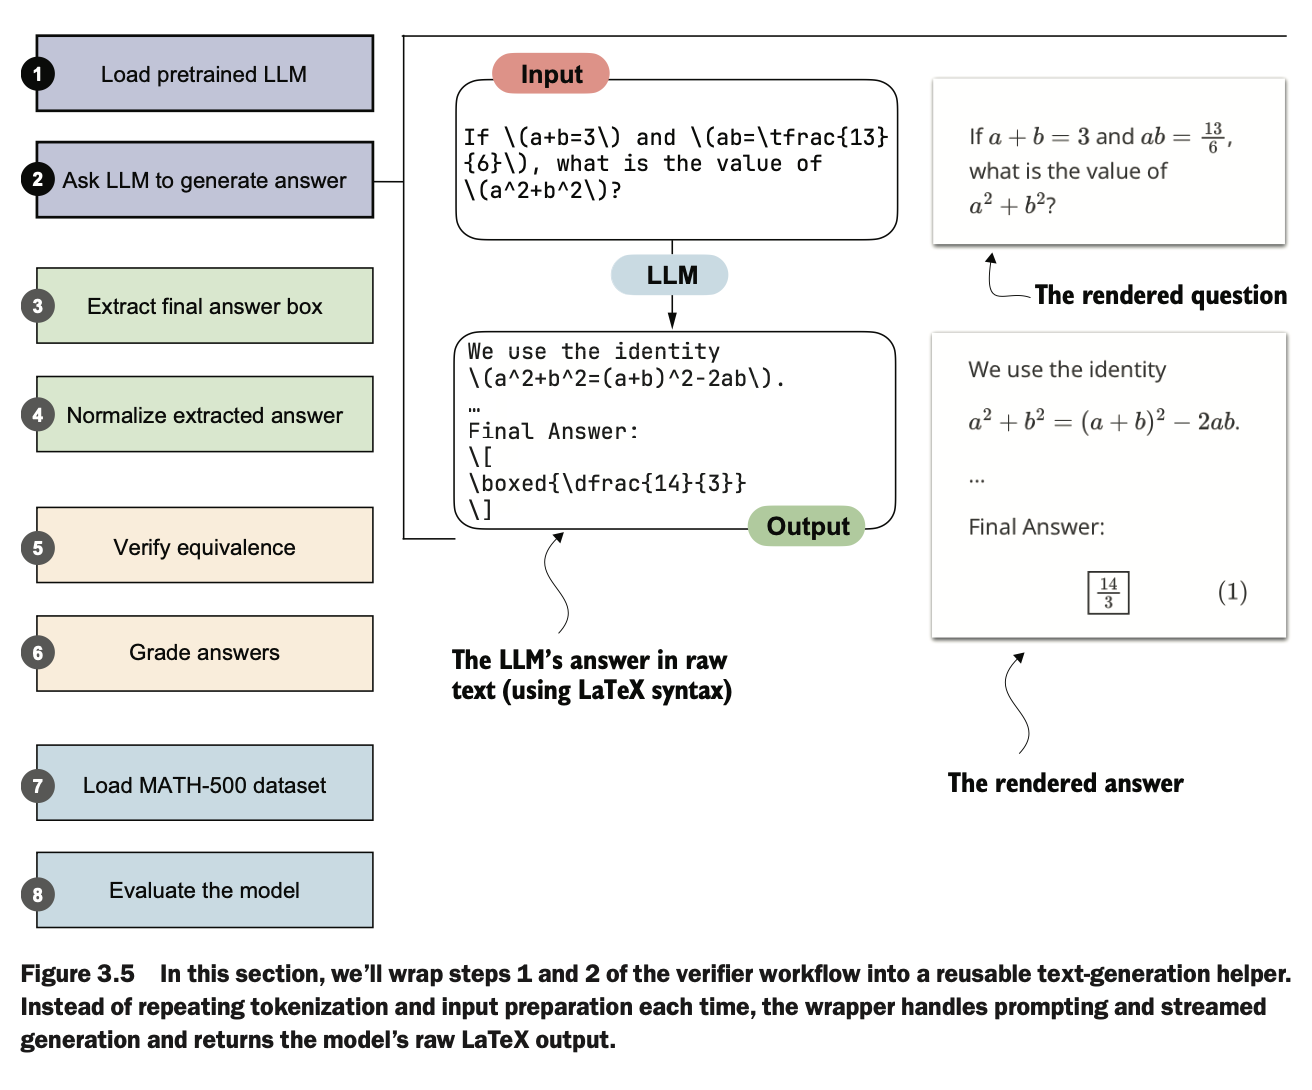


In [8]:
# Listing 3.3 A wrapper for streamed text generation


def generate_text_stream_concat(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens,
    verbose=False,
):
    # Encode prompt text into token IDs and place on device.
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)

    generated_ids = []

    # Stream tokens one by one using cached generation.
    for token in generate_text_basic_stream_cache(
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        # Optionally print tokens as they are generated.
        if verbose:
            print(tokenizer.decode(next_token_id.tolist()), end="", flush=True)

    # Decode all generated IDs into final text string.
    return tokenizer.decode(generated_ids)


skip_portion = False

if not skip_portion:
    generated_text = generate_text_stream_concat(
        model,
        tokenizer,
        prompt,
        device,
        max_new_tokens=2048,
        verbose=True,  # Using False will suppress the live token-by-token printing.
    )

 To find the value of \( a^2 + b^2 \) given that \( a + b = 3 \) and \( ab = \frac{13}{6} \), we can use the following algebraic identity:

\[
a^2 + b^2 = (a + b)^2 - 2ab
\]

**Step 1:** Substitute the given values into the equation.

\[
a^2 + b^2 = (3)^2 - 2 \left( \frac{13}{6} \right)
\]

**Step 2:** Calculate \( (3)^2 \).

\[
(3)^2 = 9
\]

**Step 3:** Calculate \( 2 \times \frac{13}{6} \).

\[
2 \times \frac{13}{6} = \frac{26}{6} = \frac{13}{3}
\]

**Step 4:** Subtract the second result from the first.

\[
a^2 + b^2 = 9 - \frac{13}{3}
\]

**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.

\[
9 = \frac{27}{3}
\]

\[
a^2 + b^2 = \frac{27}{3} - \frac{13}{3} = \frac{14}{3}
\]

**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]

In [9]:
# The answer box we want to extract
model_answer = r"""... some explanation...
**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]
"""

In [10]:
# Listing 3.4 Extracting answer boxes


def get_last_boxed(text):
    # Find the last occurrence of "\boxed"
    boxed_start_idx = text.rfind(r"\boxed")
    if boxed_start_idx == -1:
        return None

    # Get position after "\boxed"
    current_idx = boxed_start_idx + len(r"\boxed")

    # Skip any whitespace after "\boxed"
    while current_idx < len(text) and text[current_idx].isspace():
        current_idx += 1

    # Expect an opening brace "{"
    if current_idx >= len(text) or text[current_idx] != "{":
        return None

    # Parse the braces with nesting
    current_idx += 1
    brace_depth = 1
    content_start_idx = current_idx

    while current_idx < len(text) and brace_depth > 0:
        char = text[current_idx]
        if char == "{":
            brace_depth += 1
        elif char == "}":
            brace_depth -= 1
        current_idx += 1

    # Account for unbalanced braces
    if brace_depth != 0:
        return None

    # Extract content inside the outermost braces
    return text[content_start_idx : current_idx - 1]

In [11]:
extracted_answer = get_last_boxed(model_answer)
print(extracted_answer)

\dfrac{14}{3}


In [12]:
from IPython.display import Math

display(Math(r"\dfrac{14}{3}"))

<IPython.core.display.Math object>

In [13]:
import re

RE_NUMBER = re.compile(r"-?(?:\d+/\d+|\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)")


def extract_final_candidate(text, fallback="number_then_full"):
    # Default return value if nothing matches
    result = ""

    if text:
        # Prefer the last boxed expression if present
        boxed = get_last_boxed(text.strip())
        if boxed:
            result = boxed.strip().strip("$ ")

        # If no boxed expression, try fallback
        elif fallback in ("number_then_full", "number_only"):
            m = RE_NUMBER.findall(text)
            if m:
                # Use last number
                result = m[-1]
            elif fallback == "number_then_full":
                # Else return full text if no number found
                result = text
    return result


""" 
This extract_final_candidate function provides fallback settings in case no boxed
answer is found, as follows:
  "number_then_full" (the default): Pick the last simple number; otherwise, pick
   the whole text.
  "number_only": Pick the last simple number; otherwise, return an empty string ""
  "none": Extract only the boxed content; otherwise, return an empty string ""
"""

' \nThis extract_final_candidate function provides fallback settings in case no boxed\nanswer is found, as follows:\n  "number_then_full" (the default): Pick the last simple number; otherwise, pick\n   the whole text.\n  "number_only": Pick the last simple number; otherwise, return an empty string ""\n  "none": Extract only the boxed content; otherwise, return an empty string ""\n'

In [14]:
print(extract_final_candidate(model_answer))

print(extract_final_candidate(r"\boxed{ 14/3. }"))

print(extract_final_candidate("abc < > 14/3 abc"))

\dfrac{14}{3}
14/3.
14/3


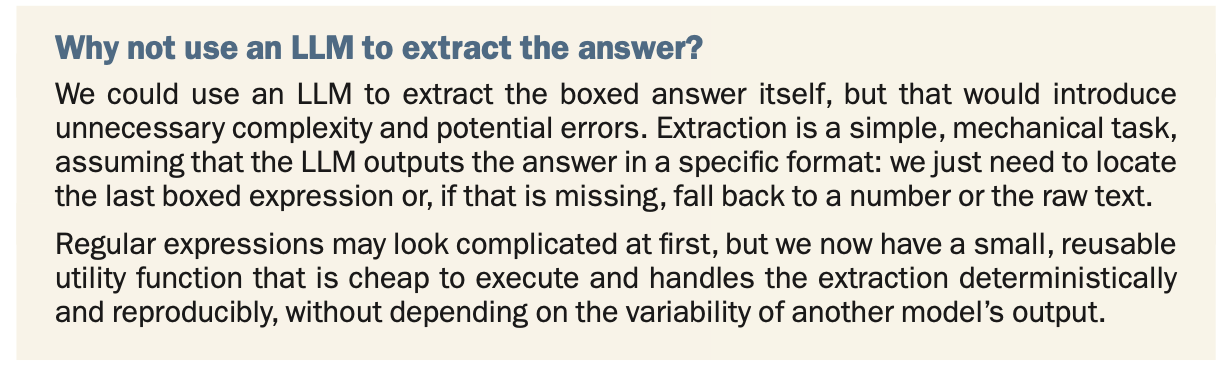


# 3.5 Normalizing the extracted answer

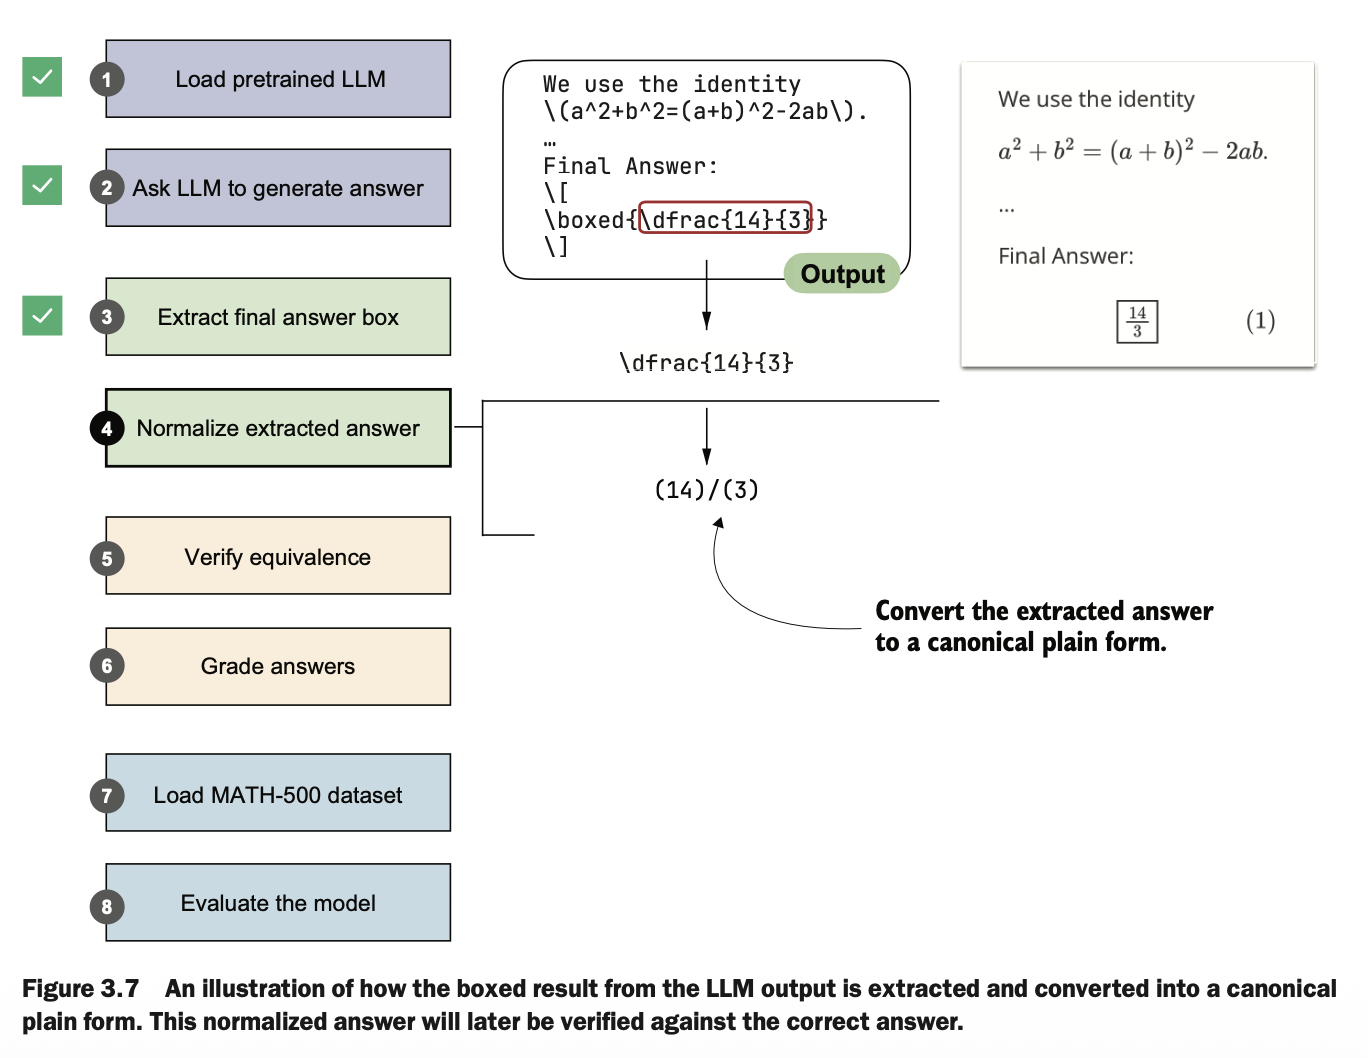


In [15]:
LATEX_FIXES = [  # Latex formatting to be replaced
    (r"\\left\s*", ""),
    (r"\\right\s*", ""),
    (r"\\,|\\!|\\;|\\:", ""),
    (r"\\cdot", "*"),
    (r"\u00B7|\u00D7", "*"),
    (r"\\\^\\circ", ""),
    (r"\\dfrac", r"\\frac"),
    (r"\\tfrac", r"\\frac"),
    (r"°", ""),
]

RE_SPECIAL = re.compile(r"<\|[^>]+?\|>")  # strip chat special tokens like <|assistant|>


def normalize_text(text):
    if not text:
        return ""
    text = RE_SPECIAL.sub("", text).strip()
    SUPERSCRIPT_MAP = {
        "⁰": "0",
        "¹": "1",
        "²": "2",
        "³": "3",
        "⁴": "4",
        "⁵": "5",
        "⁶": "6",
        "⁷": "7",
        "⁸": "8",
        "⁹": "9",
        "⁺": "+",
        "⁻": "-",
        "⁽": "(",
        "⁾": ")",
    }

    # Strip leading multiple-choice labels
    # E.g., like "c. 3" -> 3, or "b: 2" -> 2
    match = re.match(r"^[A-Za-z]\s*[.:]\s*(.+)$", text)
    if match:
        text = match.group(1)

    # Remove angle-degree markers
    text = re.sub(r"\^\s*\{\s*\\circ\s*\}", "", text)  # ^{\circ}
    text = re.sub(r"\^\s*\\circ", "", text)  # ^\circ
    text = text.replace("°", "")  # Unicode degree

    # unwrap \text{...} if the whole string is wrapped
    match = re.match(r"^\\text\{(?P<x>.+?)\}$", text)
    if match:
        text = match.group("x")

    # strip inline/display math wrappers \( \) \[ \]
    text = re.sub(r"\\\(|\\\)|\\\[|\\\]", "", text)

    # light LaTeX canonicalization
    for pat, rep in LATEX_FIXES:
        text = re.sub(pat, rep, text)

    def convert_superscripts(s, base=None):
        converted = "".join(
            SUPERSCRIPT_MAP[ch] if ch in SUPERSCRIPT_MAP else ch for ch in s
        )
        if base is None:
            return converted
        return f"{base}**{converted}"

    # convert unicode superscripts into exponent form (e.g., 2² -> 2**2)m
    text = re.sub(
        r"([0-9A-Za-z\)\]\}])([⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻]+)",
        lambda m: convert_superscripts(m.group(2), base=m.group(1)),
        text,
    )
    text = convert_superscripts(text)

    # numbers/roots
    text = text.replace("\\%", "%").replace("$", "").replace("%", "")
    text = re.sub(
        r"\\sqrt\s*\{([^}]*)\}",
        lambda match: f"sqrt({match.group(1)})",
        text,
    )
    text = re.sub(
        r"\\sqrt\s+([^\\\s{}]+)",
        lambda match: f"sqrt({match.group(1)})",
        text,
    )

    # fractions
    text = re.sub(
        r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}",
        lambda match: f"({match.group(1)})/({match.group(2)})",
        text,
    )
    text = re.sub(
        r"\\frac\s+([^\s{}]+)\s+([^\s{}]+)",
        lambda match: f"({match.group(1)})/({match.group(2)})",
        text,
    )

    # exponent and mixed numbers
    text = text.replace("^", "**")
    text = re.sub(
        r"(?<=\d)\s+(\d+/\d+)",
        lambda match: "+" + match.group(1),
        text,
    )

    # 1,234 -> 1234
    text = re.sub(
        r"(?<=\d),(?=\d\d\d(\D|$))",
        "",
        text,
    )

    return text.replace("{", "").replace("}", "").strip().lower()

In [16]:
print(normalize_text(extract_final_candidate(model_answer)))

print(normalize_text(r"\text{\[\frac{14}{3}\]}"))

(14)/(3)
(14)/(3)


# 3.6 Verifying mathematical equivalence

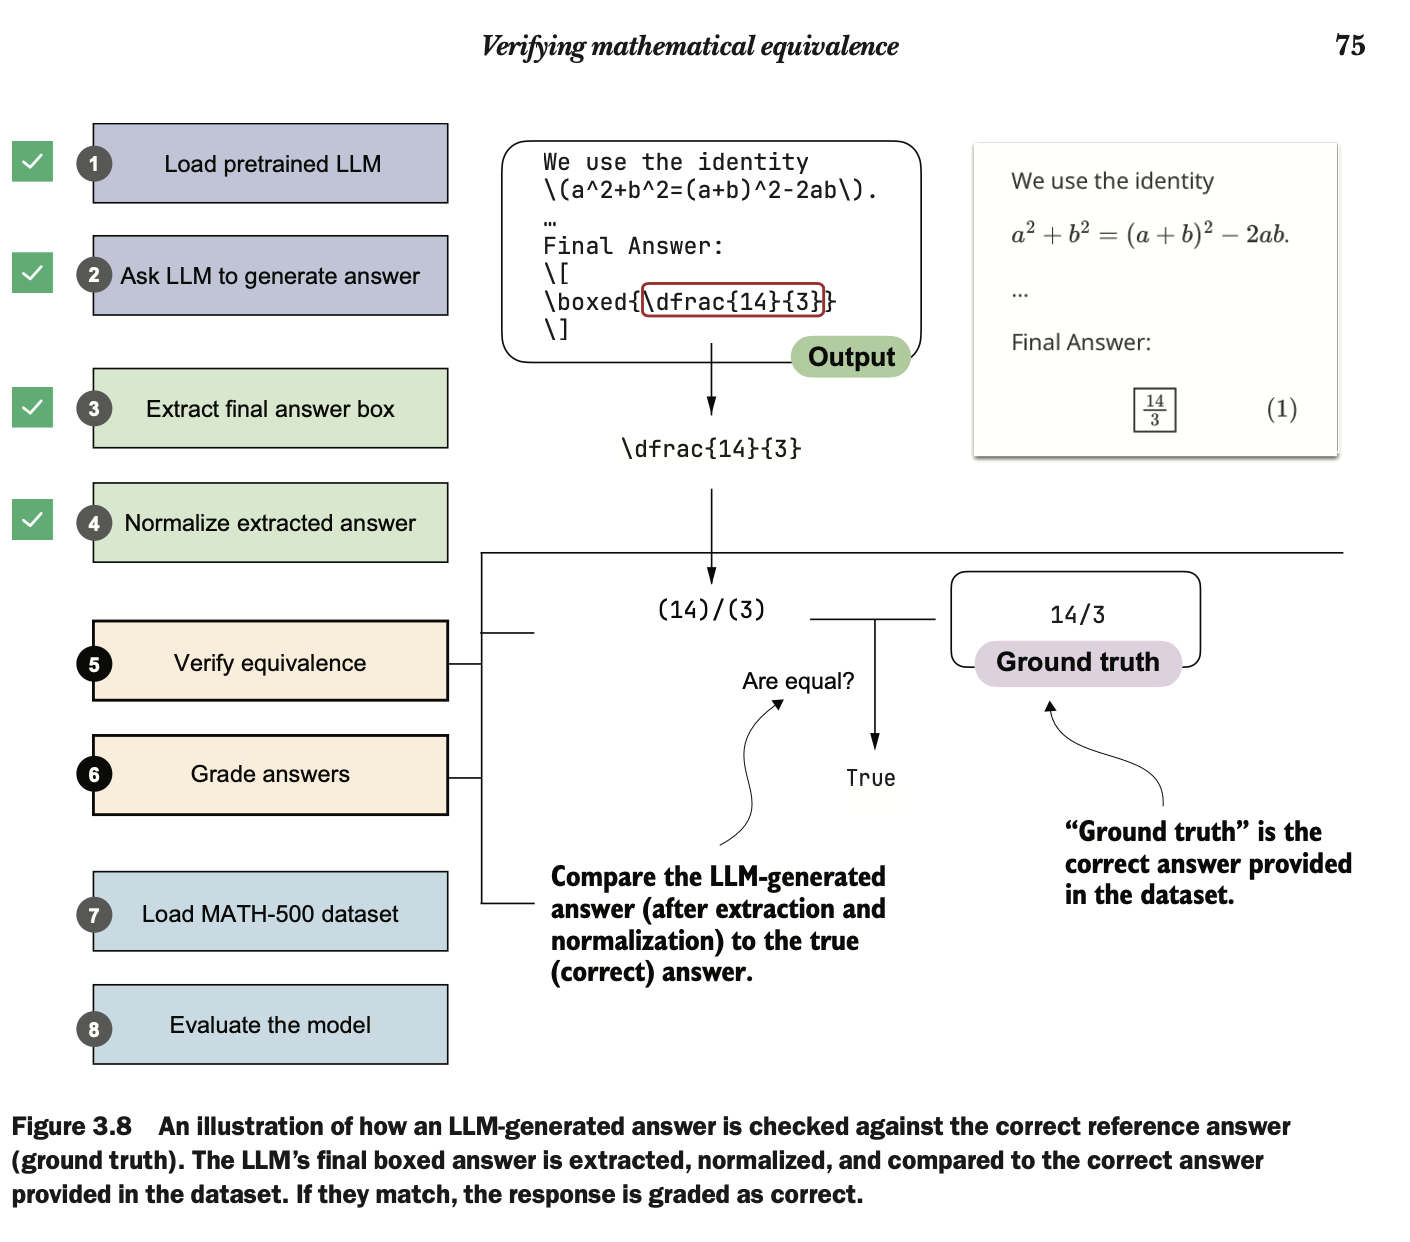


In [17]:
from sympy.parsing import sympy_parser as spp
from sympy.core.sympify import SympifyError
from tokenize import TokenError
from sympy.polys.polyerrors import PolynomialError


def sympy_parser(expr):

    # To avoid crashing on long garbage responses
    # that some badly trained models (chapter 6) may emit
    if expr is None or len(expr) > 2000:
        return None
    try:
        return spp.parse_expr(
            expr,
            transformations=(
                # Standard transformations like handling parentheses
                *spp.standard_transformations,
                # Allow omitted multiplication symbols (e.g., "2x" -> 2*x")
                spp.implicit_multiplication_application,
            ),
            # Evaluate during parsing so simple constants simplify (e.g., 2+3 -> 5)
            evaluate=True,
        )
    except (
        SympifyError,
        SyntaxError,
        TypeError,
        AttributeError,
        IndexError,
        TokenError,
        ValueError,
        PolynomialError,
    ):  # type: ignore
        return None

In [18]:
print(sympy_parser(normalize_text(extract_final_candidate(model_answer))))

14/3


In [19]:
print(sympy_parser("28/6"))

14/3


In [20]:
from sympy import simplify


def equality_check(expr_gtruth, expr_pred):
    # First, check if the two expressions are exactly the same string
    if expr_gtruth == expr_pred:
        return True

    # Parse both expressions into SymPy objects (returns None if parsing fails)
    gtruth, pred = sympy_parser(expr_gtruth), sympy_parser(expr_pred)

    # If both expressions were parsed successfully, try symbolic comparison
    if gtruth is not None and pred is not None:
        try:
            # If the difference is 0, they are equivalent
            return simplify(gtruth - pred) == 0
        except (SympifyError, TypeError):
            pass

    return False

In [21]:
print(equality_check(normalize_text("13/4."), normalize_text(r"(13)/(4)")))

True


In [22]:
print(equality_check(normalize_text("0.5"), normalize_text(r"(1)/(2)")))

True


In [23]:
print(equality_check(normalize_text("14/3"), normalize_text("15/3")))

False


In [24]:
print(equality_check(normalize_text("(14/3, 2/3)"), normalize_text("(14/3, 4/6)")))

False


# 3.7 Grading answers

- Now we’ll build on the previous section’s mathematical equality-checking function to
  implement a robust grading function that can also handle tuple-like expressions, such
  as correctly comparing "(14/3, 2/3)" and "(14/3, 4/6)".

- First, we’ll implement a Python helper function that splits such tuple-like expressions
  into individual subparts.


In [25]:
# Listing 3.9 A helper function to split tuple-like expressions


def split_into_parts(text):
    result = [text]

    if text:
        # Check if text looks like a tuple or list, e.g. "(a, b)" or "[a, b]"
        if (
            len(text) >= 2
            and text[0] in "(["
            and text[-1] in ")]"
            and "," in text[1:-1]
        ):
            ## Split on commas inside brackets and strip whitespace
            items = [p.strip() for p in text[1:-1].split(",")]
            if all(items):
                result = items
    else:
        # If text is empty, return an empty list
        result = []

    return result

In [26]:
split_into_parts(normalize_text(r"(14/3, 2/3)"))

['14/3', '2/3']

In [ ]:
# Listing 3.10 Function to grade predicted answers against the ground truth

# gt = grand truth


def grade_answer(pred_text, gt_text):
    result = False  # Default outcome if checks fail

    # Only continue if both inputs are non-empty strings.
    if pred_text is not None and gt_text is not None:

        gt_parts = split_into_parts(normalize_text(gt_text))

        pred_parts = split_into_parts(normalize_text(pred_text))

        # Ensure both sides have the same number of valid parts.
        if gt_parts and pred_parts and len(gt_parts) == len(pred_parts):

            result = all(
                equality_check(gt, pred) for gt, pred in zip(gt_parts, pred_parts)
            )  # Check each part for mathematical equivalence.

    return result

In [30]:
grade_answer("14/3", r"\frac{14}{3}")
grade_answer(r"(14/3, 2/3)", "(14/3, 4/6)")

True

In [31]:
# Define test cases: (name, prediction, ground truth, expected result)
tests = [
    ("check_1", "3/4", r"\frac{3}{4}", True),
    ("check_2", "(3)/(4)", r"3/4", True),
    ("check_3", r"\frac{\sqrt{8}}{2}", "sqrt(2)", True),
    ("check_4", r"\( \frac{1}{2} + \frac{1}{6} \)", "2/3", True),
    ("check_5", "(1, 2)", r"(1,2)", True),
    ("check_6", "(2, 1)", "(1, 2)", False),
    ("check_7", "(1, 2, 3)", "(1, 2)", False),
    ("check_8", "0.5", "1/2", True),
    ("check_9", "0.3333333333", "1/3", False),
    ("check_10", "1,234/2", "617", True),
    ("check_11", r"\text{2/3}", "2/3", True),
    ("check_12", "50%", "1/2", False),
    ("check_13", r"2\cdot 3/4", "3/2", True),
    ("check_14", r"90^\circ", "90", True),
    ("check_15", r"\left(\frac{3}{4}\right)", "3/4", True),
    ("check_16", r"2²", "2**2", True),
]


def run_demos_table(tests):
    header = ("Test", "Expect", "Got", "Status")
    rows = []
    for name, pred, gtruth, expect in tests:
        got = grade_answer(pred, gtruth)  # Run equality check
        status = "PASS" if got == expect else "FAIL"
        rows.append((name, str(expect), str(got), status))

    data = [header] + rows

    # Compute max width for each column to align table nicely
    col_widths = [max(len(row[i]) for row in data) for i in range(len(header))]

    # Print table row by row
    for row in data:
        line = " | ".join(row[i].ljust(col_widths[i]) for i in range(len(header)))
        print(line)

    # Print summary of passed tests
    passed = sum(r[3] == "PASS" for r in rows)
    print(f"\nPassed {passed}/{len(rows)}")

In [32]:
run_demos_table(tests)

Test     | Expect | Got   | Status
check_1  | True   | True  | PASS  
check_2  | True   | True  | PASS  
check_3  | True   | True  | PASS  
check_4  | True   | True  | PASS  
check_5  | True   | True  | PASS  
check_6  | False  | False | PASS  
check_7  | False  | False | PASS  
check_8  | True   | True  | PASS  
check_9  | False  | False | PASS  
check_10 | True   | True  | PASS  
check_11 | True   | True  | PASS  
check_12 | False  | False | PASS  
check_13 | True   | True  | PASS  
check_14 | True   | True  | PASS  
check_15 | True   | True  | PASS  
check_16 | True   | True  | PASS  

Passed 16/16


# 3.8 Loading the evaluation dataset

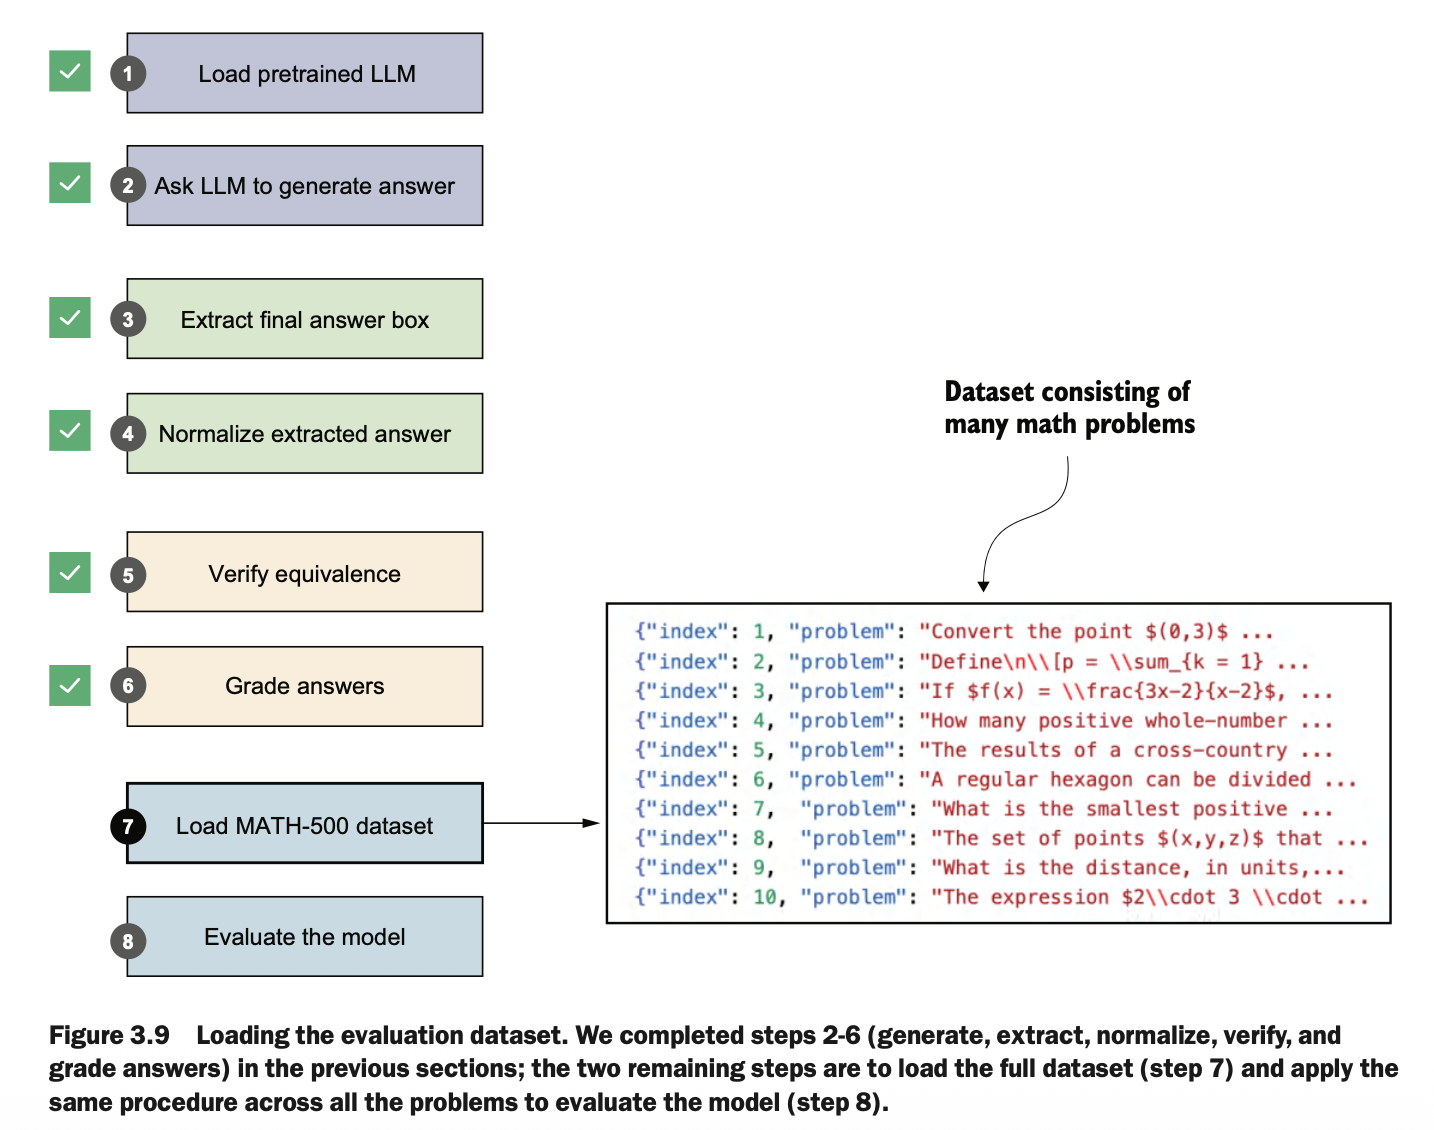


In [34]:
import json
import requests


def load_math500_test(local_path="math500_test.json", save_copy=True):
    local_path = Path(local_path)
    url = (
        "https://raw.githubusercontent.com/rasbt/reasoning-from-scratch/"
        "main/ch03/01_main-chapter-code/math500_test.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        data = r.json()

        if save_copy:  # Saves a local copy
            with local_path.open("w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)

    return data


math_data = load_math500_test()
print("Number of entries:", len(math_data))

Number of entries: 500


In [35]:
from pprint import pprint

pprint(math_data[0])

{'answer': '\\left( 3, \\frac{\\pi}{2} \\right)',
 'level': 2,
 'problem': 'Convert the point $(0,3)$ in rectangular coordinates to polar '
            'coordinates.  Enter your answer in the form $(r,\\theta),$ where '
            '$r > 0$ and $0 \\le \\theta < 2 \\pi.$',
 'solution': 'We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the '
             'line connecting the origin and $(0,3),$ this line makes an angle '
             'of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n'
             '\n'
             '[asy]\n'
             'unitsize(0.8 cm);\n'
             '\n'
             'draw((-0.5,0)--(3.5,0));\n'
             'draw((0,-0.5)--(0,3.5));\n'
             'draw(arc((0,0),3,0,90),red,Arrow(6));\n'
             '\n'
             'dot((0,3), red);\n'
             'label("$(0,3)$", (0,3), W);\n'
             'dot((3,0), red);\n'
             '[/asy]\n'
             '\n'
             'Therefore, the polar coordinates are $\\boxed{\\left( 3, '
             '\\frac

# 3.9 Evaluating the model

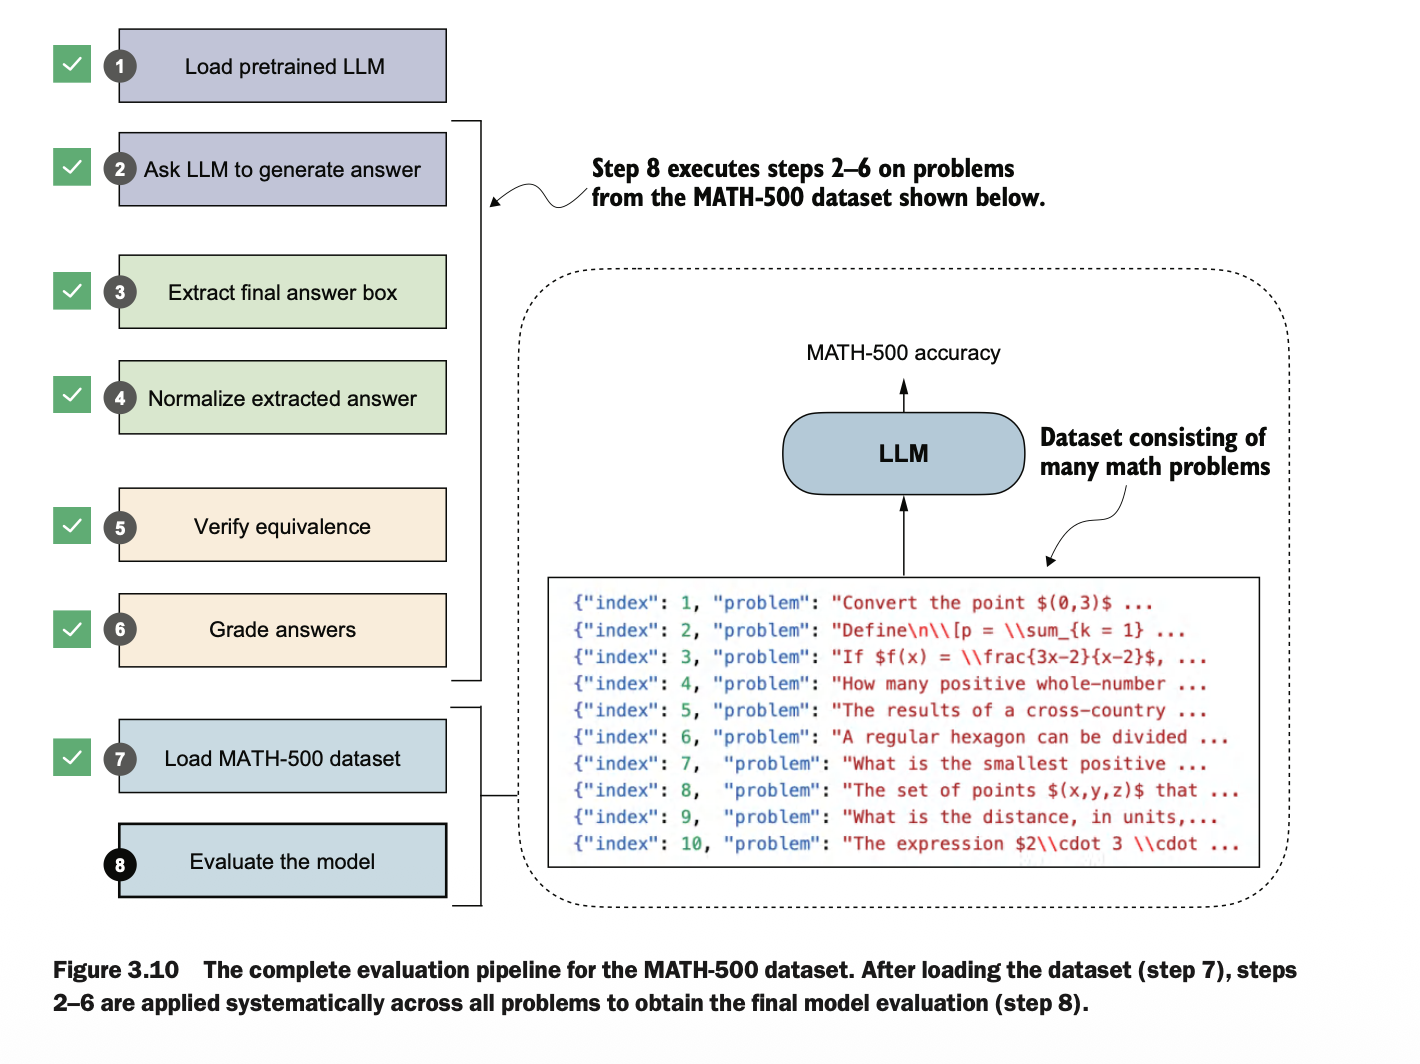


In [37]:
# Listing 3.13 Function to render a prompt template for math evaluation


def render_prompt(prompt):
    template = (
        "You are a helpful math assistant.\n"
        "Answer the question and write the final result on a new line as:\n"
        "\\boxed{ANSWER}\n\n"
        f"Question:\n{prompt}\n\nAnswer:"
    )
    return template

In [39]:
prompt = (  # Same prompt we used at the beginning of the chapter
    r"If $a+b=3$ and $ab=\tfrac{13}{6}$, " r"what is the value of $a^2+b^2$?"
)
prompt_fmt = render_prompt(prompt)
print(prompt_fmt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
If $a+b=3$ and $ab=\tfrac{13}{6}$, what is the value of $a^2+b^2$?

Answer:


In [40]:
generated_text = generate_text_stream_concat(
    model, tokenizer, prompt_fmt, device, max_new_tokens=2048, verbose=True
)

 \boxed{10}

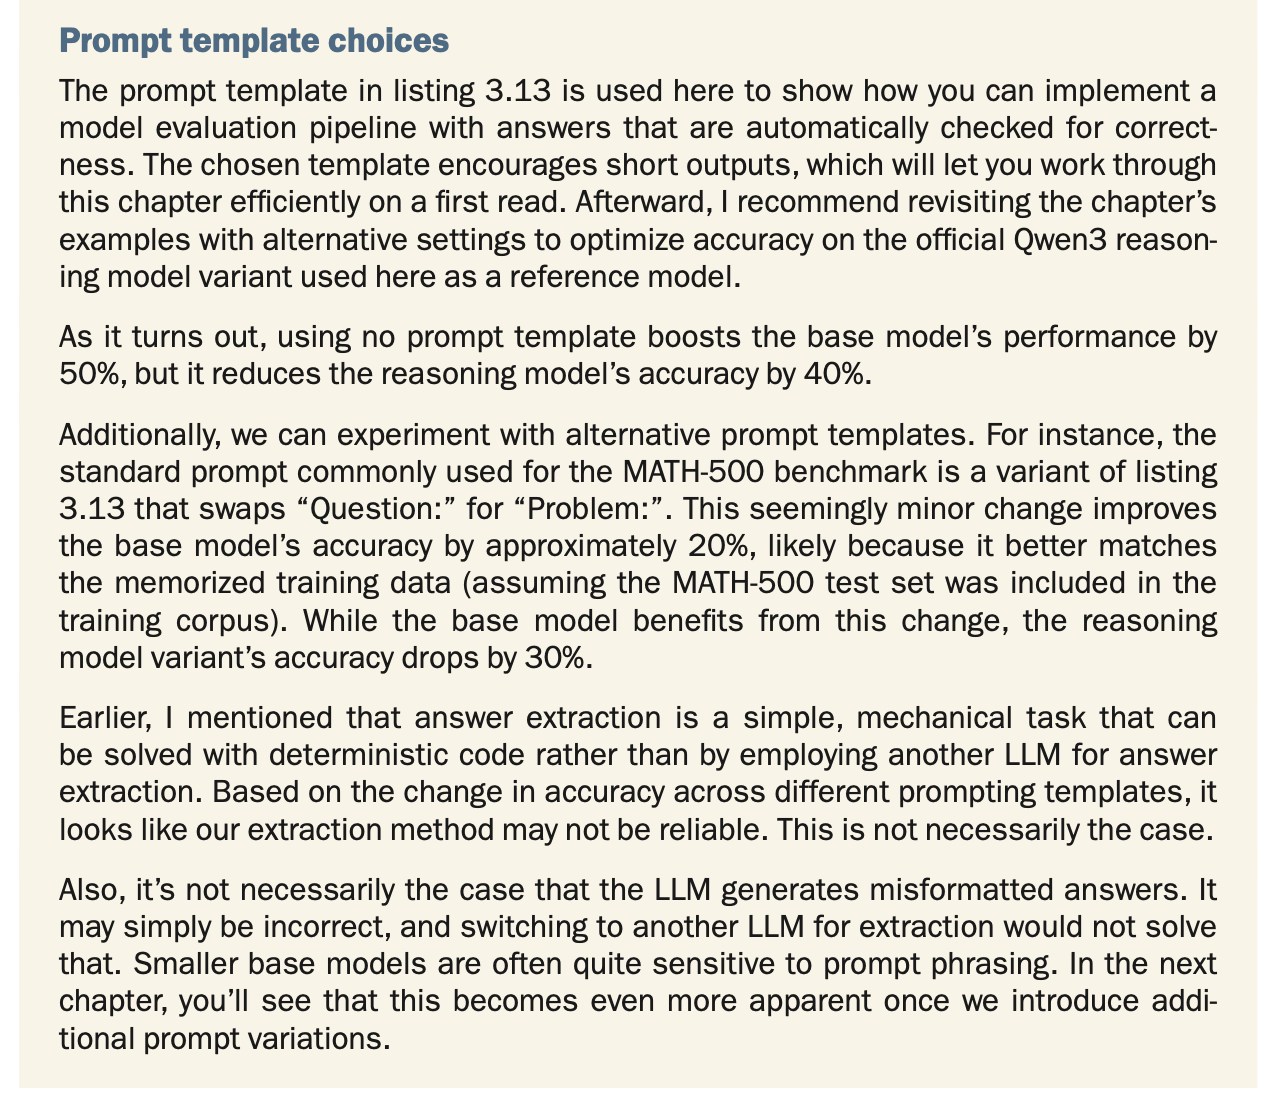


In [41]:
def mini_eval_demo(model, tokenizer, device):
    ex = {  # Test example with "problem" and "answer" fields
        "problem": "Compute 1/2 + 1/6.",
        "answer": "2/3",
    }
    prompt = render_prompt(ex["problem"])  # 1. Apply prompt template
    gen_text = generate_text_stream_concat(  # 2. Generate response
        model,
        tokenizer,
        prompt,
        device,
        max_new_tokens=64,
    )
    pred_answer = extract_final_candidate(gen_text)  # 3. Extract and normalize answer
    is_correct = grade_answer(pred_answer, ex["answer"])  # 4. Grade answer
    print(f"Device: {device}")
    print(f"Prediction: {pred_answer}")
    print(f"Ground truth: {ex['answer']}")
    print(f"Correct: {is_correct}")

In [43]:
mini_eval_demo(model, tokenizer, device)

Device: mps
Prediction: 1/3
Ground truth: 2/3
Correct: False


# Listing 3.15

## End-to-end model evaluation pipeline for MATH-500 dataset :


In [ ]:
import time


# Helper function to calculate remaining time
def eta_progress_message(
    processed,
    total,
    start_time,
    show_eta=False,
    label="Progress",
):
    progress = f"{label}: {processed}/{total}"
    pad_width = len(f"{label}: {total}/{total} | ETA: 00h 00m 00s")
    if not show_eta or processed <= 0:
        return progress.ljust(pad_width)

    elapsed = time.time() - start_time
    if elapsed <= 0:
        return progress.ljust(pad_width)

    remaining = max(total - processed, 0)

    if processed:
        avg_time = elapsed / processed
        eta_seconds = avg_time * remaining
    else:
        eta_seconds = 0

    eta_seconds = max(int(round(eta_seconds)), 0)
    minutes, rem_seconds = divmod(eta_seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        eta = f"{hours}h {minutes:02d}m {rem_seconds:02d}s"
    elif minutes:
        eta = f"{minutes:02d}m {rem_seconds:02d}s"
    else:
        eta = f"{rem_seconds:02d}s"

    message = f"{progress} | ETA: {eta}"
    return message.ljust(pad_width)


def evaluate_math500_stream(
    model,
    tokenizer,
    device,
    math_data,
    out_path=None,
    max_new_tokens=512,
    verbose=False,
):

    if out_path is None:
        dev_name = str(device).replace(
            ":", "-"
        )  # Make filename compatible with Windows
        out_path = Path(f"math500-{dev_name}.jsonl")

    num_examples = len(math_data)
    num_correct = 0
    start_time = time.time()

    with open(out_path, "w", encoding="utf-8") as f:  # Save results for inspection
        for i, row in enumerate(math_data, start=1):
            prompt = render_prompt(row["problem"])  # 1. Apply prompt template
            gen_text = generate_text_stream_concat(  # 2. Generate response
                model,
                tokenizer,
                prompt,
                device,
                max_new_tokens=max_new_tokens,
                verbose=verbose,
            )

            extracted = extract_final_candidate(  # 3. Extract and normalize answer
                gen_text
            )
            is_correct = grade_answer(extracted, row["answer"])  # 4. Grade answer
            num_correct += int(is_correct)

            record = {  # Record to be saved for inspection
                "index": i,
                "problem": row["problem"],
                "gtruth_answer": row["answer"],
                "generated_text": gen_text,
                "extracted": extracted,
                "correct": bool(is_correct),
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

            progress_msg = eta_progress_message(
                processed=i,
                total=num_examples,
                start_time=start_time,
                show_eta=True,
                label="MATH-500",
            )
            print(progress_msg, end="\r", flush=True)
            if verbose:  # Print responses during the generation process
                print(
                    f"\n\n{'='*50}\n{progress_msg}\n"
                    f"{'='*50}\nExtracted: {extracted}\n"
                    f"Expected:  {row['answer']}\n"
                    f"Correct so far: {num_correct}\n{'-'*50}"
                )

    # Print summary information
    seconds_elapsed = time.time() - start_time
    acc = num_correct / num_examples if num_examples else 0.0
    print(f"\nAccuracy: {acc*100:.1f}% ({num_correct}/{num_examples})")
    print(f"Total time: {seconds_elapsed/60:.1f} min")
    print(f"Logs written to: {out_path}")
    return num_correct, num_examples, acc

In [49]:
print("Model:", WHICH_MODEL)
print("Device:", device)
num_correct, num_examples, acc = evaluate_math500_stream(
    model,
    tokenizer,
    device,
    math_data=math_data[10:20],
    max_new_tokens=2048,
    verbose=False,
)

Model: base
Device: mps
MATH-500: 10/10 | ETA: 00s        
Accuracy: 10.0% (1/10)
Total time: 0.1 min
Logs written to: math500-mps.jsonl


In [ ]:
# Loading the .jsonl file programmatically
dev_name = str(device).replace(":", "-")
local_path = f"math500_{WHICH_MODEL}-{dev_name}.jsonl"

results = []
with open(local_path, "r") as f:
    for line in f:
        if line.strip():
            results.append(json.loads(line))

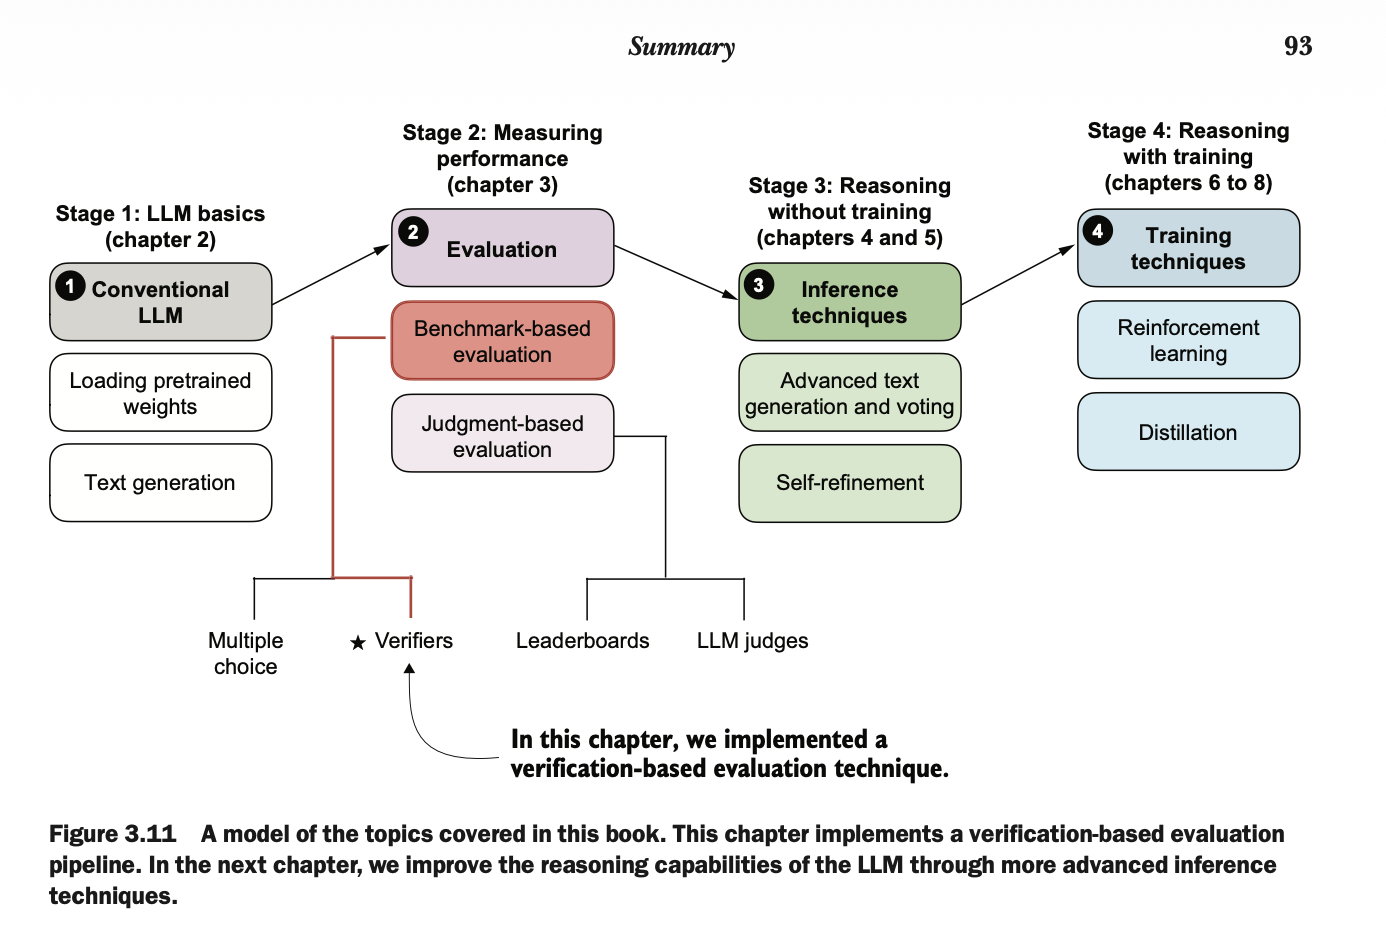